# ML Olist 

## Projet : Analyse des ventes et prédiction de la satisfaction client sur la plateforme e-commerce Olist

Ce notebook reprend le notebook Machine Learning et l'explique étape par étape.

L'objectif est de comprendre :

- pourquoi on fait les jointures ;
- pourquoi on crée certaines variables ;
- pourquoi on choisit une classification binaire ;
- pourquoi on compare plusieurs modèles ;
- comment interpréter les métriques ;
- comment lire les résultats.

## Objectif du modèle

Nous voulons prédire si un client sera satisfait ou non après une commande.

La satisfaction est construite à partir de la note client :

- `review_score >= 4` : client satisfait ;
- `review_score <= 3` : client non satisfait.

C'est donc un problème de **classification binaire**.

## 1. Importation des bibliothèques

In [1]:
# pandas permet de manipuler les données sous forme de tableaux appelés DataFrames.
import pandas as pd

# numpy permet de faire des calculs numériques et de créer des conditions.
import numpy as np

# matplotlib permet de créer des graphiques simples.
import matplotlib.pyplot as plt

# seaborn permet de créer des graphiques statistiques plus lisibles.
import seaborn as sns

# train_test_split sert à séparer les données en données d'entraînement et données de test.
from sklearn.model_selection import train_test_split

# ColumnTransformer permet d'appliquer des traitements différents aux colonnes numériques et catégorielles.
from sklearn.compose import ColumnTransformer

# Pipeline permet d'enchaîner automatiquement le nettoyage des variables et le modèle.
from sklearn.pipeline import Pipeline

# OneHotEncoder transforme les variables textuelles en colonnes numériques.
from sklearn.preprocessing import OneHotEncoder

# StandardScaler met les variables numériques sur une échelle comparable.
from sklearn.preprocessing import StandardScaler

# SimpleImputer permet de remplacer les valeurs manquantes restantes.
from sklearn.impute import SimpleImputer

# LogisticRegression est un modèle simple, utilisé comme modèle de référence.
from sklearn.linear_model import LogisticRegression

# RandomForestClassifier est un modèle basé sur plusieurs arbres de décision.
from sklearn.ensemble import RandomForestClassifier

# GradientBoostingClassifier est un modèle d'arbres qui corrige progressivement ses erreurs.
from sklearn.ensemble import GradientBoostingClassifier

# classification_report affiche les métriques principales : precision, recall, f1-score.
from sklearn.metrics import classification_report

# confusion_matrix permet de voir les bonnes et mauvaises prédictions.
from sklearn.metrics import confusion_matrix

# roc_auc_score mesure la capacité du modèle à séparer les clients satisfaits et non satisfaits.
from sklearn.metrics import roc_auc_score

# joblib permet de sauvegarder le modèle entraîné.
import joblib

# os permet de créer des dossiers si nécessaire.
import os

### Commentaire

Cette cellule prépare l'environnement Python.

Les bibliothèques les plus importantes ici sont :

- `pandas` pour les données ;
- `scikit-learn` pour le Machine Learning ;
- `matplotlib` et `seaborn` pour les graphiques ;
- `joblib` pour sauvegarder le modèle final.

## 2. Chargement des fichiers nettoyés

In [2]:
# Les fichiers nettoyés doivent avoir été générés par Cleaning_Olist.ipynb.
PROCESSED_DIR = "data/processed"

customers = pd.read_csv(r"C:\Users\azoua\Documents\Formations_chez_JEDHA\DATA_ANALYSTE\Projet_final\Olist-Ecommerce-Satisfaction\Olist-Ecommerce-Satisfaction\data\processed\customers_clean.csv")
orders = pd.read_csv(r"C:\Users\azoua\Documents\Formations_chez_JEDHA\DATA_ANALYSTE\Projet_final\Olist-Ecommerce-Satisfaction\Olist-Ecommerce-Satisfaction\data\processed\orders_clean.csv")
order_items = pd.read_csv(r"C:\Users\azoua\Documents\Formations_chez_JEDHA\DATA_ANALYSTE\Projet_final\Olist-Ecommerce-Satisfaction\Olist-Ecommerce-Satisfaction\data\processed\order_items_clean.csv")
order_payments = pd.read_csv(r"C:\Users\azoua\Documents\Formations_chez_JEDHA\DATA_ANALYSTE\Projet_final\Olist-Ecommerce-Satisfaction\Olist-Ecommerce-Satisfaction\data\processed\order_payments_clean.csv")
order_reviews = pd.read_csv(r"C:\Users\azoua\Documents\Formations_chez_JEDHA\DATA_ANALYSTE\Projet_final\Olist-Ecommerce-Satisfaction\Olist-Ecommerce-Satisfaction\data\processed\order_reviews_clean.csv")
products = pd.read_csv(r"C:\Users\azoua\Documents\Formations_chez_JEDHA\DATA_ANALYSTE\Projet_final\Olist-Ecommerce-Satisfaction\Olist-Ecommerce-Satisfaction\data\processed\products_clean.csv")
sellers = pd.read_csv(r"C:\Users\azoua\Documents\Formations_chez_JEDHA\DATA_ANALYSTE\Projet_final\Olist-Ecommerce-Satisfaction\Olist-Ecommerce-Satisfaction\data\processed\sellers_clean.csv")
translation = pd.read_csv(r"C:\Users\azoua\Documents\Formations_chez_JEDHA\DATA_ANALYSTE\Projet_final\Olist-Ecommerce-Satisfaction\Olist-Ecommerce-Satisfaction\data\processed\translation_clean.csv")

### Commentaire

Cette cellule charge les datasets nettoyés.

Nous ne partons pas des fichiers bruts, car le Machine Learning doit être construit sur des données déjà préparées :

- types corrigés ;
- dates converties ;
- doublons traités ;
- valeurs manquantes principales gérées.

La table `geolocation` n'est pas utilisée dans cette première version du modèle, car nous avons déjà des variables géographiques simples dans `customers` : `customer_state` et `customer_city`.

Elle pourra être ajoutée plus tard pour créer une variable plus avancée, par exemple la distance entre client et vendeur.

## 3. Vérification du chargement

In [3]:
# Cette cellule permet de vérifier que les datasets ont bien été chargés.
# shape affiche le nombre de lignes et de colonnes de chaque table.
print("customers :", customers.shape)
print("orders :", orders.shape)
print("order_items :", order_items.shape)
print("order_payments :", order_payments.shape)
print("order_reviews :", order_reviews.shape)
print("products :", products.shape)
print("sellers :", sellers.shape)
print("translation :", translation.shape)

customers : (99441, 5)
orders : (99441, 8)
order_items : (112650, 7)
order_payments : (103886, 5)
order_reviews : (99224, 7)
products : (32951, 9)
sellers : (3095, 4)
translation : (71, 2)


### Commentaire des résultats

Le résultat attendu est une liste de dimensions.

Exemple :

```text
orders : (99441, 8)
```

Cela signifie que la table `orders` contient 99 441 lignes et 8 colonnes.

Si une erreur apparaît ici, cela signifie généralement :

- que le dossier `data/processed` n'existe pas ;
- que le notebook de nettoyage n'a pas encore été exécuté ;
- que les noms des fichiers exportés ne correspondent pas.

## 4. Préparation de la table Orders

In [4]:
# On crée une copie de la table orders pour éviter de modifier directement la table chargée.
orders_ml = orders.copy()

# Ces colonnes représentent les dates importantes du parcours de commande.
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Comme les fichiers CSV ne conservent pas toujours les types datetime,
# on reconvertit les colonnes de dates.
for col in date_cols:
    orders_ml[col] = pd.to_datetime(orders_ml[col], errors="coerce")

# On calcule le délai réel de livraison en jours.
# C'est la différence entre la date de livraison réelle et la date d'achat.
orders_ml["delivery_time_days"] = (
    orders_ml["order_delivered_customer_date"] - orders_ml["order_purchase_timestamp"]
).dt.days

# On calcule le délai estimé en jours.
# C'est la différence entre la date de livraison estimée et la date d'achat.
orders_ml["estimated_delivery_time_days"] = (
    orders_ml["order_estimated_delivery_date"] - orders_ml["order_purchase_timestamp"]
).dt.days

# On calcule le retard de livraison.
# Si le résultat est positif, la commande est arrivée après la date estimée.
# Si le résultat est négatif, la commande est arrivée avant la date estimée.
orders_ml["delivery_delay_days"] = (
    orders_ml["order_delivered_customer_date"] - orders_ml["order_estimated_delivery_date"]
).dt.days

# On crée une variable binaire pour indiquer si la commande est en retard.
# 1 signifie en retard, 0 signifie pas en retard.
orders_ml["is_late"] = np.where(orders_ml["delivery_delay_days"] > 0, 1, 0)

# On garde uniquement les colonnes utiles pour le modèle.
orders_features = orders_ml[
    [
        "order_id",
        "customer_id",
        "order_status",
        "delivery_time_days",
        "estimated_delivery_time_days",
        "delivery_delay_days",
        "is_late"
    ]
]

# On affiche les premières lignes pour vérifier la table obtenue.
orders_features.head()

,order_id,customer_id,order_status,delivery_time_days,estimated_delivery_time_days,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,8.0,15,-8.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,13.0,19,-6.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,9.0,26,-18.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,13.0,26,-13.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2.0,12,-10.0,0


### Commentaire des résultats

Cette table contient maintenant des variables très importantes pour prédire la satisfaction client.

Pourquoi ?

En e-commerce, la satisfaction dépend souvent de la livraison :

- une commande livrée rapidement a plus de chances d'être bien notée ;
- une commande en retard a plus de risques d'avoir une mauvaise note ;
- une commande annulée ou non livrée peut fortement impacter la satisfaction.

Les valeurs manquantes dans `delivery_time_days` ou `delivery_delay_days` sont normales pour certaines commandes non livrées.
Elles seront traitées plus tard par `SimpleImputer`.

## 5. Agrégation de la table Order Items

In [5]:
# La table order_items contient une ligne par article commandé.
# Or notre modèle doit avoir une ligne par commande.
# Nous devons donc agréger les articles au niveau order_id.
items_agg = (
    order_items
    .groupby("order_id")
    .agg(
        # Nombre total d'articles dans la commande.
        nb_items=("order_item_id", "count"),

        # Montant total des produits dans la commande.
        total_price=("price", "sum"),

        # Prix moyen des articles dans la commande.
        avg_price=("price", "mean"),

        # Total des frais de livraison.
        total_freight=("freight_value", "sum"),

        # Nombre de vendeurs différents dans la commande.
        nb_sellers=("seller_id", "nunique")
    )
    .reset_index()
)

# Affichage des premières lignes.
items_agg.head()

,order_id,nb_items,total_price,avg_price,total_freight,nb_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,199.90,18.14,1


### Commentaire des résultats

Le résultat est une table avec une ligne par commande.

Exemple :

- `nb_items = 3` signifie que la commande contient 3 articles ;
- `total_price = 150` signifie que le montant des articles est de 150 ;
- `total_freight = 25` signifie que les frais de livraison sont de 25 ;
- `nb_sellers = 2` signifie que la commande implique 2 vendeurs différents.

Ces variables peuvent influencer la satisfaction.
Par exemple, une commande avec plusieurs vendeurs peut avoir plus de risques de complexité logistique.

## 6. Récupération des informations produits

In [6]:
# On joint order_items avec products pour récupérer les caractéristiques produits.
items_products = order_items.merge(
    products[
        [
            "product_id",
            "product_category_name",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ],
    on="product_id",
    how="left"
)

# On trie les articles par commande et par numéro d'article.
items_products_sorted = items_products.sort_values(["order_id", "order_item_id"])

# Pour simplifier, on prend le premier produit de chaque commande.
# C'est une approximation acceptable pour une première version académique.
main_product = (
    items_products_sorted
    .groupby("order_id")
    .first()
    .reset_index()
)

# On garde uniquement les informations produits utiles.
main_product = main_product[
    [
        "order_id",
        "product_category_name",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
]

# Affichage des premières lignes.
main_product.head()

,order_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,moveis_decoracao,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,perfumaria,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ferramentas_jardim,3750.0,35.0,40.0,30.0


### Commentaire des résultats

Cette étape ajoute les informations du produit principal de la commande.

Limite importante :

Une commande peut contenir plusieurs produits.
Ici, pour simplifier, nous prenons seulement le premier produit.

C'est une limite que tu peux mentionner en soutenance :

> Pour une première version du modèle, nous avons choisi la catégorie du premier produit comme catégorie principale de la commande. Une amélioration future serait de créer des variables plus précises sur toutes les catégories présentes dans chaque commande.

## 7. Agrégation de la table Payments

In [7]:
# La table order_payments peut contenir plusieurs lignes pour une même commande.
# On agrège donc les paiements au niveau order_id.
payments_agg = (
    order_payments
    .groupby("order_id")
    .agg(
        # Montant total payé pour la commande.
        total_payment_value=("payment_value", "sum"),

        # Nombre maximum de séquences de paiement.
        nb_payment_sequences=("payment_sequential", "max"),

        # Nombre maximum de mensualités.
        max_payment_installments=("payment_installments", "max")
    )
    .reset_index()
)

# On récupère le premier type de paiement utilisé pour chaque commande.
payment_type_main = (
    order_payments
    .sort_values(["order_id", "payment_sequential"])
    .groupby("order_id")
    .first()
    .reset_index()[["order_id", "payment_type"]]
)

# On joint les informations numériques de paiement avec le type de paiement.
payments_features = payments_agg.merge(
    payment_type_main,
    on="order_id",
    how="left"
)

# Affichage des premières lignes.
payments_features.head()

,order_id,total_payment_value,nb_payment_sequences,max_payment_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3,credit_card


### Commentaire des résultats

Cette table résume les informations de paiement au niveau commande.

Variables importantes :

- `total_payment_value` : montant total payé ;
- `max_payment_installments` : nombre de mensualités ;
- `payment_type` : type de paiement principal.

Ces variables peuvent influencer l'expérience client, mais elles sont généralement moins déterminantes que la livraison.

## 8. Création de la target avec les avis clients

In [8]:
# Une commande peut avoir un ou plusieurs avis.
# On calcule donc la note moyenne par commande.
reviews_agg = (
    order_reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean")
    )
    .reset_index()
)

# Création de la variable cible binaire.
# Si la note moyenne est supérieure ou égale à 4, le client est considéré satisfait.
reviews_agg["is_satisfied"] = np.where(reviews_agg["review_score"] >= 4, 1, 0)

# Affichage des premières lignes.
reviews_agg.head()

,order_id,review_score,is_satisfied
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


### Commentaire des résultats

Cette cellule crée la variable la plus importante du projet : `is_satisfied`.

Interprétation :

- `1` : client satisfait ;
- `0` : client non satisfait.

Pourquoi choisir 4 comme seuil ?

Dans beaucoup d'analyses de satisfaction, les notes 4 et 5 sont considérées comme positives.
Les notes 1, 2 et 3 indiquent une satisfaction faible, moyenne ou négative.

## 9. Préparation des variables clients

In [9]:
# On garde uniquement les variables client utiles pour le modèle.
customers_features = customers[
    [
        "customer_id",
        "customer_state",
        "customer_city"
    ]
]

# Affichage des premières lignes.
customers_features.head()

,customer_id,customer_state,customer_city
0,06b8999e2fba1a1fbc88172c00ba8bc7,SP,franca
1,18955e83d337fd6b2def6b18a428ac77,SP,sao bernardo do campo
2,4e7b3e00288586ebd08712fdd0374a03,SP,sao paulo
3,b2b6027bc5c5109e529d4dc6358b12c3,SP,mogi das cruzes
4,4f2d8ab171c80ec8364f7c12e35b23ad,SP,campinas


### Commentaire des résultats

Nous gardons ici la localisation du client :

- État ;
- ville.

Ces variables peuvent aider le modèle car certaines zones peuvent être associées à des délais de livraison plus longs ou à des expériences client différentes.

## 10. Construction de la table finale pour le Machine Learning

In [10]:
# On commence avec les informations de commande et livraison.
ml_data = orders_features.copy()

# On ajoute les informations clients.
ml_data = ml_data.merge(
    customers_features,
    on="customer_id",
    how="left"
)

# On ajoute les informations agrégées sur les articles.
ml_data = ml_data.merge(
    items_agg,
    on="order_id",
    how="left"
)

# On ajoute les informations du produit principal.
ml_data = ml_data.merge(
    main_product,
    on="order_id",
    how="left"
)

# On ajoute les informations de paiement.
ml_data = ml_data.merge(
    payments_features,
    on="order_id",
    how="left"
)

# On ajoute les avis clients et la target.
# Le how="inner" signifie qu'on garde seulement les commandes qui ont un avis client.
ml_data = ml_data.merge(
    reviews_agg,
    on="order_id",
    how="inner"
)

# On affiche les dimensions de la table finale.
print("Dimensions de la table ML :", ml_data.shape)

# On affiche les premières lignes.
ml_data.head()

Dimensions de la table ML : (98673, 25)


,order_id,customer_id,order_status,delivery_time_days,estimated_delivery_time_days,delivery_delay_days,is_late,customer_state,customer_city,nb_items,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_payment_value,nb_payment_sequences,max_payment_installments,payment_type,review_score,is_satisfied
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,8.0,15,-8.0,0,SP,sao paulo,1.0,...,500.0,19.0,8.0,13.0,38.71,3.0,1.0,credit_card,4.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,13.0,19,-6.0,0,BA,barreiras,1.0,...,400.0,19.0,13.0,19.0,141.46,1.0,1.0,boleto,4.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,9.0,26,-18.0,0,GO,vianopolis,1.0,...,420.0,24.0,19.0,21.0,179.12,1.0,3.0,credit_card,5.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,13.0,26,-13.0,0,RN,sao goncalo do amarante,1.0,...,450.0,30.0,10.0,20.0,72.20,1.0,1.0,credit_card,5.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2.0,12,-10.0,0,SP,santo andre,1.0,...,250.0,51.0,15.0,15.0,28.62,1.0,1.0,credit_card,5.0,1


### Commentaire des résultats

Cette cellule construit la table centrale du Machine Learning.

Important :

Le modèle apprend au niveau de la commande.
Chaque ligne représente une commande.

Le `how="inner"` avec `reviews_agg` est volontaire :
nous ne pouvons pas entraîner un modèle sans target.
Donc les commandes sans avis client sont exclues de l'entraînement.

C'est normal et justifiable.

## 11. Vérification de la table Machine Learning

In [11]:
# On vérifie les valeurs manquantes dans la table ML.
ml_data.isna().sum()

order_id                           0
customer_id                        0
order_status                       0
delivery_time_days              2843
estimated_delivery_time_days       0
delivery_delay_days             2843
is_late                            0
customer_state                     0
customer_city                      0
nb_items                         756
total_price                      756
avg_price                        756
total_freight                    756
nb_sellers                       756
product_category_name            756
product_weight_g                 756
product_length_cm                756
product_height_cm                756
product_width_cm                 756
total_payment_value                1
nb_payment_sequences               1
max_payment_installments           1
payment_type                       1
review_score                       0
is_satisfied                       0
dtype: int64

### Commentaire des résultats

Cette sortie montre les valeurs manquantes restantes.

Elles peuvent venir :

- de commandes non livrées ;
- de produits sans catégorie ;
- de paiements manquants ;
- de dates absentes.

À ce stade, nous ne les supprimons pas directement.
Le pipeline de preprocessing les traitera automatiquement avec `SimpleImputer`.

In [12]:
# On vérifie la répartition de la variable cible.
ml_data["is_satisfied"].value_counts(normalize=True)

is_satisfied
1    0.770505
0    0.229495
Name: proportion, dtype: float64

### Commentaire des résultats

Cette cellule affiche la proportion de clients satisfaits et non satisfaits.

Exemple possible :

```text
1    0.77
0    0.23
```

Cela signifie que 77 % des commandes avec avis sont satisfaites et 23 % non satisfaites.

C'est important, car si une classe est beaucoup plus fréquente que l'autre, l'accuracy seule peut être trompeuse.

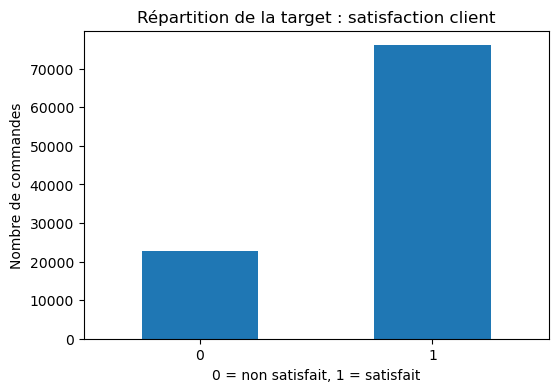

In [13]:
# On visualise la répartition de la target.
ml_data["is_satisfied"].value_counts().sort_index().plot(kind="bar", figsize=(6, 4))

# Titre du graphique.
plt.title("Répartition de la target : satisfaction client")

# Nom de l'axe horizontal.
plt.xlabel("0 = non satisfait, 1 = satisfait")

# Nom de l'axe vertical.
plt.ylabel("Nombre de commandes")

# On garde les labels horizontaux.
plt.xticks(rotation=0)

# Affichage du graphique.
plt.show()

### Commentaire du graphique

Ce graphique permet de voir si les classes sont équilibrées.

Si la barre `1` est beaucoup plus grande que la barre `0`, cela signifie que la majorité des clients sont satisfaits.

Dans ce cas, il faut regarder attentivement le recall et le f1-score de la classe `0`, car c'est souvent la classe la plus difficile à prédire.

## 12. Sélection des variables explicatives

In [14]:
# Variables numériques utilisées par le modèle.
numeric_features = [
    "delivery_time_days",
    "estimated_delivery_time_days",
    "delivery_delay_days",
    "is_late",
    "nb_items",
    "total_price",
    "avg_price",
    "total_freight",
    "nb_sellers",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "total_payment_value",
    "nb_payment_sequences",
    "max_payment_installments"
]

# Variables catégorielles utilisées par le modèle.
categorical_features = [
    "order_status",
    "customer_state",
    "customer_city",
    "product_category_name",
    "payment_type"
]

# X contient les variables explicatives.
X = ml_data[numeric_features + categorical_features]

# y contient la variable cible à prédire.
y = ml_data["is_satisfied"]

# Affichage des dimensions.
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (98673, 21)
Dimensions de y : (98673,)


### Commentaire des résultats

`X` contient les variables utilisées pour prédire.

`y` contient la réponse attendue : satisfait ou non satisfait.

Nous avons retiré :

- `order_id`, car c'est un identifiant ;
- `customer_id`, car c'est un identifiant ;
- `review_score`, car il sert à construire la target.

Utiliser `review_score` comme variable explicative serait une fuite de données, car cela reviendrait à donner la réponse au modèle.

## 13. Séparation Train / Test

In [15]:
# On sépare les données en train et test.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Affichage des dimensions des jeux de données.
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (78938, 21)
X_test : (19735, 21)
y_train : (78938,)
y_test : (19735,)


### Commentaire des résultats

Le train sert à entraîner les modèles.

Le test sert à évaluer les modèles sur des données qu'ils n'ont jamais vues.

Nous utilisons `stratify=y` pour garder la même proportion de clients satisfaits et non satisfaits dans le train et dans le test.

C'est une bonne pratique lorsque la target n'est pas parfaitement équilibrée.

## 14. Préprocessing des variables

In [16]:
# Traitement des variables numériques.
numeric_transformer = Pipeline(
    steps=[
        # Les valeurs manquantes numériques sont remplacées par la médiane.
        ("imputer", SimpleImputer(strategy="median")),

        # Les variables numériques sont standardisées.
        ("scaler", StandardScaler())
    ]
)

# Traitement des variables catégorielles.
categorical_transformer = Pipeline(
    steps=[
        # Les valeurs manquantes catégorielles sont remplacées par unknown.
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),

        # Les catégories textuelles sont transformées en colonnes numériques.
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Le ColumnTransformer applique le bon traitement à chaque groupe de colonnes.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Commentaire

Les modèles de Machine Learning ne comprennent pas directement les textes comme :

```text
credit_card
SP
sao paulo
```

Le `OneHotEncoder` transforme ces textes en colonnes numériques.

Exemple simplifié :

| payment_type | devient |
|---|---|
| credit_card | payment_type_credit_card = 1 |
| boleto | payment_type_boleto = 1 |

Le preprocessing est intégré dans un pipeline pour éviter les erreurs et rendre le modèle réutilisable.

## 15. Modèle 1 — Logistic Regression

In [17]:
# Création du pipeline complet : preprocessing + modèle.
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

# Entraînement du modèle sur les données d'entraînement.
logistic_model.fit(X_train, y_train)

# Prédiction des classes sur les données de test.
y_pred_log = logistic_model.predict(X_test)

# Prédiction des probabilités de satisfaction.
y_proba_log = logistic_model.predict_proba(X_test)[:, 1]

# Affichage des métriques.
print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

# Affichage du score ROC AUC.
print("ROC AUC :", roc_auc_score(y_test, y_proba_log))

Logistic Regression
              precision    recall  f1-score   support

           0       0.49      0.52      0.50      4529
           1       0.85      0.84      0.85     15206

    accuracy                           0.77     19735
   macro avg       0.67      0.68      0.68     19735
weighted avg       0.77      0.77      0.77     19735

ROC AUC : 0.7253827446702585


### Commentaire des résultats

La Logistic Regression sert de modèle de référence.

Elle permet de répondre à la question :

> Est-ce qu'un modèle simple arrive déjà à prédire correctement la satisfaction ?

Dans le `classification_report`, regarde surtout :

- la ligne `0` : performance sur les clients non satisfaits ;
- la ligne `1` : performance sur les clients satisfaits ;
- le `f1-score` : équilibre entre precision et recall ;
- le `ROC AUC` : capacité globale du modèle à séparer les deux classes.

`class_weight="balanced"` aide le modèle à ne pas trop privilégier la classe majoritaire.

## 16. Modèle 2 — Random Forest

In [18]:
# Création du pipeline Random Forest.
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

# Entraînement du modèle.
random_forest_model.fit(X_train, y_train)

# Prédiction des classes.
y_pred_rf = random_forest_model.predict(X_test)

# Prédiction des probabilités.
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Affichage des métriques.
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

# Affichage du ROC AUC.
print("ROC AUC :", roc_auc_score(y_test, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.77      0.33      0.46      4529
           1       0.83      0.97      0.89     15206

    accuracy                           0.82     19735
   macro avg       0.80      0.65      0.68     19735
weighted avg       0.82      0.82      0.79     19735

ROC AUC : 0.7297921309548034


### Commentaire des résultats

La Random Forest est plus puissante que la Logistic Regression.

Elle peut mieux capter des relations complexes.

Exemple :

- un retard de livraison peut être plus grave pour certaines catégories ;
- les frais de livraison peuvent influencer différemment selon le montant total ;
- certaines villes ou États peuvent avoir des comportements spécifiques.

Si la Random Forest améliore le ROC AUC ou le f1-score, cela signifie que les relations dans les données sont probablement non linéaires.

## 17. Modèle 3 — Gradient Boosting

In [19]:
# Création du pipeline Gradient Boosting.
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

# Entraînement du modèle.
gradient_boosting_model.fit(X_train, y_train)

# Prédiction des classes.
y_pred_gb = gradient_boosting_model.predict(X_test)

# Prédiction des probabilités.
y_proba_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

# Affichage des métriques.
print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

# Affichage du ROC AUC.
print("ROC AUC :", roc_auc_score(y_test, y_proba_gb))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.79      0.33      0.47      4529
           1       0.83      0.97      0.90     15206

    accuracy                           0.83     19735
   macro avg       0.81      0.65      0.68     19735
weighted avg       0.82      0.83      0.80     19735

ROC AUC : 0.7369188978900411


### Commentaire des résultats

Le Gradient Boosting construit plusieurs petits modèles successifs.

Chaque modèle essaie de corriger les erreurs du précédent.

Sur des données tabulaires, il peut être très performant.

Cependant, il peut aussi être plus long à entraîner et moins simple à expliquer qu'une Logistic Regression.

## 18. Comparaison des modèles

In [20]:
# Création d'un tableau de comparaison des modèles.
model_results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "roc_auc": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb)
    ]
})

# Classement des modèles du meilleur au moins bon selon le ROC AUC.
model_results.sort_values("roc_auc", ascending=False)

,model,roc_auc
2,Gradient Boosting,0.736919
1,Random Forest,0.729792
0,Logistic Regression,0.725383


### Commentaire des résultats

Ce tableau compare les modèles selon le ROC AUC.

Plus le ROC AUC est élevé, plus le modèle sépare bien :

- les clients satisfaits ;
- les clients non satisfaits.

Un ROC AUC proche de 0.5 signifie que le modèle ne fait pas mieux que le hasard.

Un ROC AUC proche de 1 signifie que le modèle sépare très bien les deux classes.

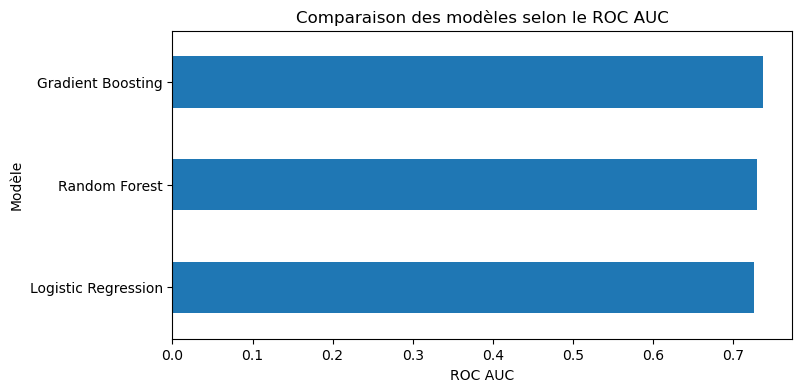

In [21]:
# Graphique de comparaison des modèles.
model_results.sort_values("roc_auc").plot(
    x="model",
    y="roc_auc",
    kind="barh",
    legend=False,
    figsize=(8, 4)
)

# Titre du graphique.
plt.title("Comparaison des modèles selon le ROC AUC")

# Nom de l'axe horizontal.
plt.xlabel("ROC AUC")

# Nom de l'axe vertical.
plt.ylabel("Modèle")

# Affichage.
plt.show()

### Commentaire du graphique

Ce graphique permet de voir rapidement quel modèle obtient le meilleur score.

Le modèle avec la barre la plus longue est le plus performant selon le ROC AUC.

Attention : il ne faut pas choisir un modèle uniquement sur un graphique.
Il faut aussi regarder le f1-score, surtout pour la classe `0` des clients non satisfaits.

## 19. Sélection automatique du meilleur modèle

In [22]:
# On récupère le nom du modèle avec le meilleur ROC AUC.
best_model_name = model_results.sort_values("roc_auc", ascending=False).iloc[0]["model"]

# Selon le nom du meilleur modèle, on sélectionne le bon pipeline et ses prédictions.
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    y_pred_best = y_pred_log
elif best_model_name == "Random Forest":
    best_model = random_forest_model
    y_pred_best = y_pred_rf
else:
    best_model = gradient_boosting_model
    y_pred_best = y_pred_gb

# Affichage du meilleur modèle.
print("Meilleur modèle :", best_model_name)

Meilleur modèle : Gradient Boosting


### Commentaire du résultat

Cette cellule choisit automatiquement le meilleur modèle selon le ROC AUC.

En soutenance, il faudra dire :

> Nous avons comparé plusieurs modèles et retenu celui qui obtenait le meilleur compromis entre performance et interprétabilité.

Si le meilleur modèle est très complexe mais n'améliore presque pas les résultats, il peut être préférable de choisir un modèle plus simple.

## 20. Matrice de confusion

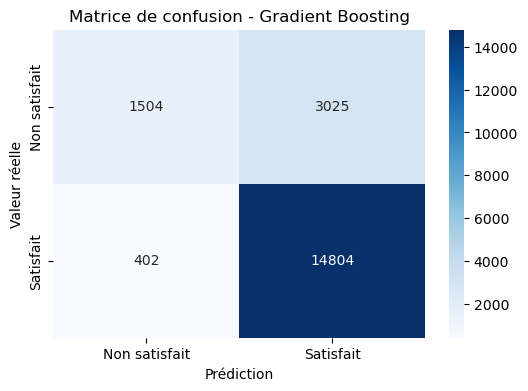

In [23]:
# Calcul de la matrice de confusion.
cm = confusion_matrix(y_test, y_pred_best)

# Création du graphique.
plt.figure(figsize=(6, 4))

# Affichage sous forme de heatmap.
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non satisfait", "Satisfait"],
    yticklabels=["Non satisfait", "Satisfait"]
)

# Titre du graphique.
plt.title(f"Matrice de confusion - {best_model_name}")

# Axe horizontal : prédictions du modèle.
plt.xlabel("Prédiction")

# Axe vertical : vraies valeurs.
plt.ylabel("Valeur réelle")

# Affichage du graphique.
plt.show()

### Commentaire de la matrice de confusion

La matrice de confusion se lit ainsi :

| | Prédit non satisfait | Prédit satisfait |
|---|---|---|
| Réel non satisfait | bonnes prédictions de non satisfaction | erreurs |
| Réel satisfait | erreurs | bonnes prédictions de satisfaction |

Les cases diagonales sont les bonnes prédictions.

Les autres cases sont les erreurs.

Dans ce projet, les erreurs importantes sont souvent les clients réellement non satisfaits mais prédits satisfaits.
Pourquoi ?
Parce que l'entreprise risque de ne pas détecter un problème client.

## 21. Sauvegarde du meilleur modèle

In [24]:
# Création du dossier models s'il n'existe pas encore.
os.makedirs("models", exist_ok=True)

# Sauvegarde du meilleur modèle entraîné.
joblib.dump(best_model, "models/best_satisfaction_model.joblib")

# Message de confirmation.
print("Modèle sauvegardé dans models/best_satisfaction_model.joblib")

Modèle sauvegardé dans models/best_satisfaction_model.joblib


### Commentaire

La sauvegarde du modèle permet de le réutiliser sans devoir le réentraîner.

Ce fichier pourra être utilisé plus tard dans :

- une API FastAPI ;
- une application Streamlit ;
- un pipeline automatisé ;
- une table de prédictions pour Power BI.

## 22. Création d'un fichier de prédictions

In [26]:
# On récupère les probabilités prédites par le meilleur modèle.
best_proba = best_model.predict_proba(X_test)[:, 1]

# On crée une copie de X_test pour stocker les prédictions.
predictions = X_test.copy()

# On ajoute la vraie satisfaction.
predictions["true_satisfaction"] = y_test.values

# On ajoute la satisfaction prédite.
predictions["predicted_satisfaction"] = y_pred_best

# On ajoute la probabilité d'être satisfait.
predictions["satisfaction_probability"] = best_proba

# On exporte le fichier de prédictions.
predictions.to_csv("../data/processed/ml_predictions.csv", index=False)

# On affiche les premières lignes.
predictions.head()

,delivery_time_days,estimated_delivery_time_days,delivery_delay_days,is_late,nb_items,total_price,avg_price,total_freight,nb_sellers,product_weight_g,...,nb_payment_sequences,max_payment_installments,order_status,customer_state,customer_city,product_category_name,payment_type,true_satisfaction,predicted_satisfaction,satisfaction_probability
24380,23.0,64,-41.0,0,2.0,299.98,149.99,165.00,1.0,8267.0,...,1.0,1.0,delivered,CE,camocim,moveis_escritorio,boleto,1,0,0.494750
53922,12.0,41,-30.0,0,1.0,130.00,130.00,18.79,1.0,950.0,...,1.0,1.0,delivered,MG,sao pedro da uniao,relogios_presentes,boleto,1,1,0.858008
60939,9.0,15,-7.0,0,1.0,186.40,186.40,20.48,1.0,1250.0,...,1.0,8.0,delivered,SP,mogi-guacu,construcao_ferramentas_construcao,credit_card,0,1,0.858936
36120,2.0,15,-14.0,0,1.0,219.99,219.99,15.14,1.0,2900.0,...,1.0,10.0,delivered,SP,sao paulo,cama_mesa_banho,credit_card,1,1,0.875941
42150,39.0,18,20.0,1,1.0,119.90,119.90,15.59,1.0,526.0,...,1.0,5.0,delivered,SP,sao paulo,perfumaria,credit_card,0,0,0.117513


### Commentaire des résultats

Le fichier `ml_predictions.csv` contient les prédictions du modèle.

Colonnes importantes :

- `true_satisfaction` : vraie valeur connue ;
- `predicted_satisfaction` : prédiction du modèle ;
- `satisfaction_probability` : probabilité que le client soit satisfait.

Ce fichier peut ensuite être chargé dans Neon ou Power BI pour afficher les prédictions.

## Conclusion générale

Ce notebook construit un premier modèle de Machine Learning complet pour prédire la satisfaction client.

La logique suivie est :

1. Charger les fichiers nettoyés.
2. Construire une table ML avec une ligne par commande.
3. Créer une target binaire à partir de `review_score`.
4. Créer des variables explicatives.
5. Séparer les données en train et test.
6. Préparer les variables numériques et catégorielles.
7. Comparer trois modèles.
8. Sélectionner le meilleur modèle.
9. Sauvegarder le modèle.
10. Exporter les prédictions.

## Modèle le plus approprié

Dans ce projet, le modèle le plus approprié sera celui qui obtient le meilleur compromis entre :

- performance ;
- capacité à détecter les clients non satisfaits ;
- simplicité d'explication.

La Logistic Regression est utile comme baseline.

La Random Forest est souvent un bon choix pour expliquer les résultats.

Le Gradient Boosting peut être plus performant sur des données tabulaires.

## À retenir pour la soutenance

Tu peux expliquer le projet ML ainsi :

> Nous avons transformé la note client en problème de classification binaire afin de prédire si une commande génèrera une satisfaction ou une insatisfaction. Les variables utilisées proviennent des commandes, paiements, produits, clients et livraisons. Nous avons comparé plusieurs modèles afin de sélectionner celui qui sépare le mieux les clients satisfaits des clients non satisfaits.